In [5]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import erf

%matplotlib inline

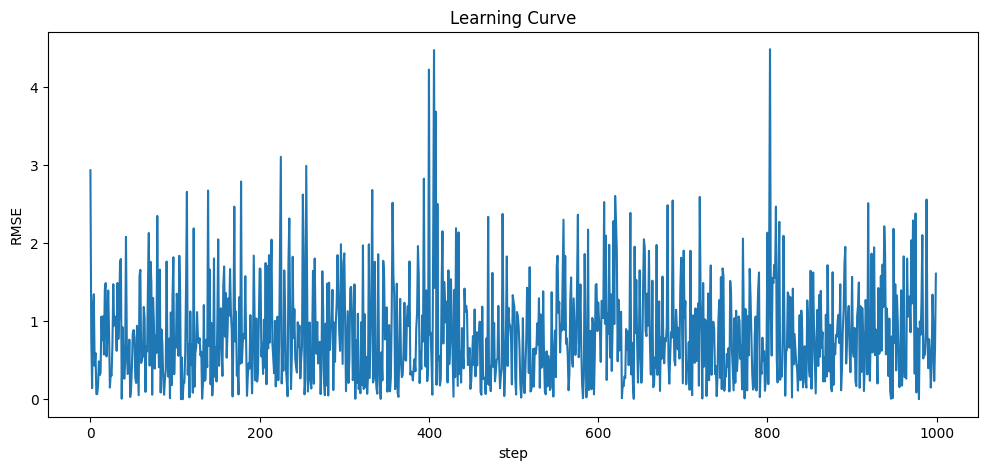

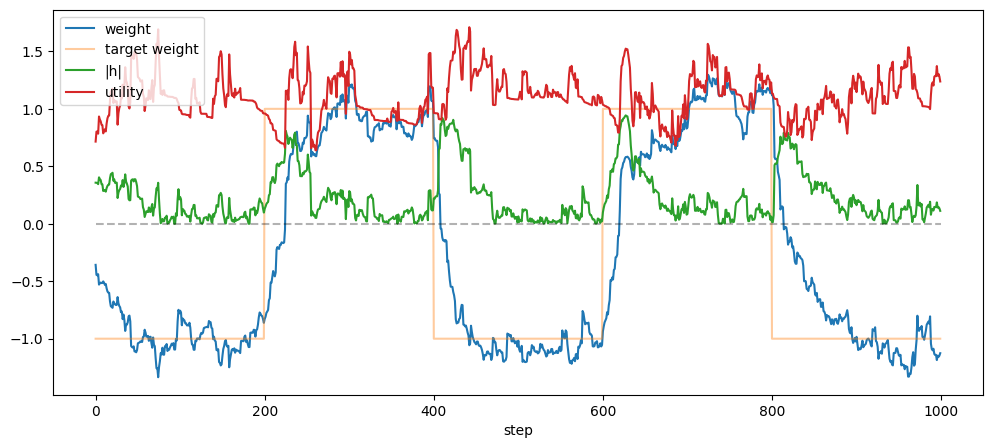

In [6]:
TRAIN_STEPS = 1000
FLIP_PERIOD = 200

target_weight = 1
step_size = 0.05
weight = 0
h = 0

rmse_history = []
weight_history = []
target_weight_history = []
h_history = []

for step in range(TRAIN_STEPS):
    if step % FLIP_PERIOD == 0:
        target_weight = -target_weight
    
    x = np.random.randn()
    target = target_weight * x + np.random.randn()
    pred = weight * x
    
    error = target - pred
    grad = error * x
    weight += step_size * grad
    h = h * np.maximum(0, 1 - step_size * x**2)  + step_size * error * x
        
    rmse_history.append(np.abs(error))
    weight_history.append(weight)
    target_weight_history.append(target_weight)
    h_history.append(h)


plt.figure(figsize=(12, 5))
plt.plot(rmse_history)
plt.title('Learning Curve')
plt.ylabel('RMSE')
plt.xlabel('step')
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(weight_history, label='weight')
plt.plot(target_weight_history, alpha=0.4, label='target weight')
plt.plot(np.abs(np.array(h_history)), label='|h|')
plt.plot(np.abs(np.array(h_history)) + np.abs(np.array(weight_history)), label='utility')
plt.hlines(0, 0, TRAIN_STEPS, alpha=0.3, linestyle='--', color='black')
plt.xlabel('step')
plt.legend()
plt.show()



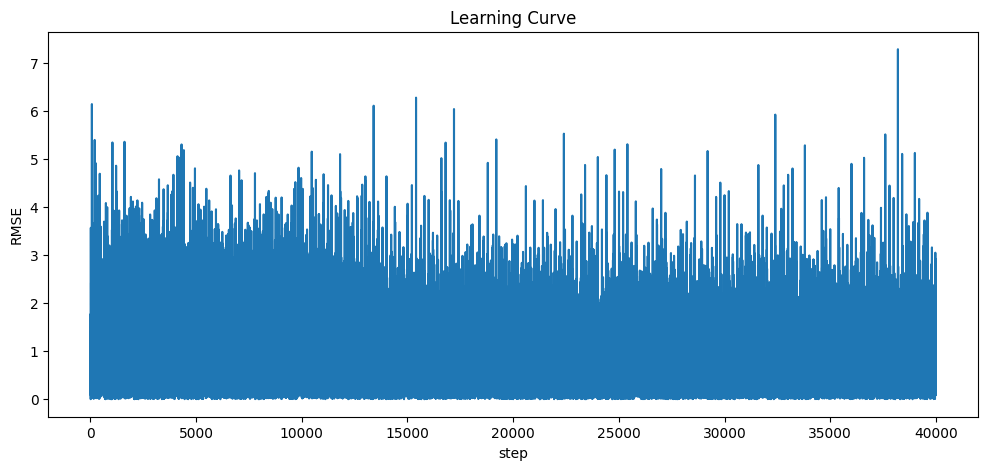

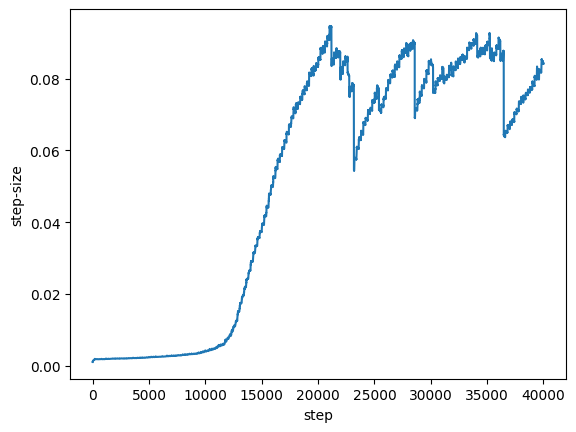

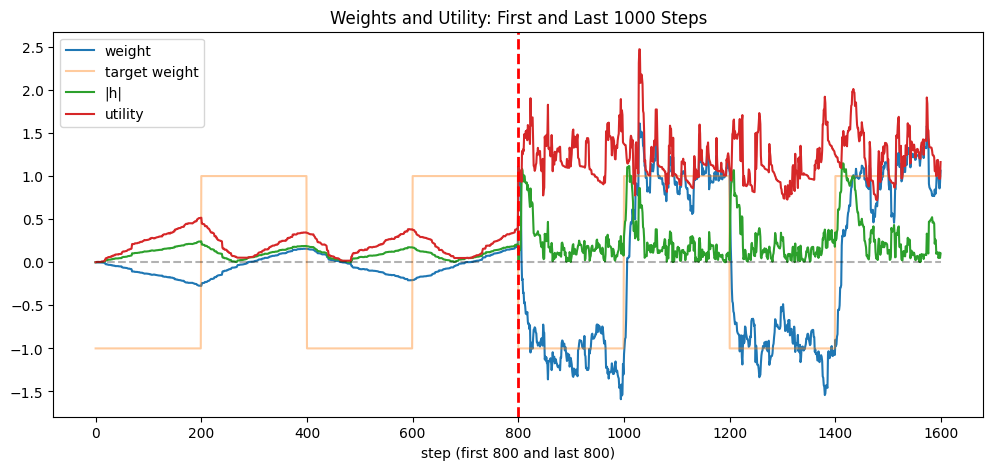

In [7]:
TRAIN_STEPS = 40_000
FLIP_PERIOD = 200

META_STEP_SIZE = 0.02
TAU = 1e4

target_weight = 1
step_size = 0.001
weight = 0
h = 0
v = 0

rmse_history = []
weight_history = []
target_weight_history = []
h_history = []
step_size_history = []

for step in range(TRAIN_STEPS):
    if step % FLIP_PERIOD == 0:
        target_weight = -target_weight
    
    x = np.random.randn()
    target = target_weight * x + np.random.randn()
    pred = weight * x
    
    error = target - pred
    grad = error * x

    # Autostep meta-update
    v = max(abs(grad * h), v + step_size * x**2 / TAU * (abs(grad * h) - v))
    if v != 0:
        step_size *= np.exp(META_STEP_SIZE * grad * h / v)
    step_size /= max(step_size * x**2, 1)

    weight += step_size * grad
    h = h * max(0, 1 - step_size * x**2) + step_size * grad
        
    rmse_history.append(np.abs(error))
    weight_history.append(weight)
    target_weight_history.append(target_weight)
    h_history.append(h)
    step_size_history.append(step_size)

plt.figure(figsize=(12, 5))
plt.plot(rmse_history)
plt.title('Learning Curve')
plt.ylabel('RMSE')
plt.xlabel('step')
plt.show()

plt.plot(step_size_history)
plt.ylabel('step-size')
plt.xlabel('step')
plt.show()

# Define how many steps to show at the start and end
n_display = 800

# Prepare data indices
start_idxs = np.arange(n_display)
end_idxs = np.arange(len(weight_history) - n_display, len(weight_history))
middle_bar = n_display  # The step where start transitions to end in concatenated plot

# Concatenate the two sections for plotting
plot_indices = np.concatenate([start_idxs, end_idxs])
steps_concat = np.arange(2 * n_display)

# Concatenate data for each series
weight_concat = np.concatenate([np.array(weight_history)[start_idxs], np.array(weight_history)[end_idxs]])
target_weight_concat = np.concatenate([np.array(target_weight_history)[start_idxs], np.array(target_weight_history)[end_idxs]])
h_concat = np.concatenate([np.array(h_history)[start_idxs], np.array(h_history)[end_idxs]])
utility_concat = np.abs(h_concat) + np.abs(weight_concat)

plt.figure(figsize=(12, 5))
plt.plot(steps_concat, weight_concat, label='weight')
plt.plot(steps_concat, target_weight_concat, alpha=0.4, label='target weight')
plt.plot(steps_concat, np.abs(h_concat), label='|h|')
plt.plot(steps_concat, utility_concat, label='utility')
plt.hlines(0, 0, 2 * n_display, alpha=0.3, linestyle='--', color='black')
plt.axvline(x=middle_bar, color='red', linestyle='--', linewidth=2.0)  # Vertical bar to separate
plt.xlabel(f'step (first {n_display} and last {n_display})')
plt.legend()
plt.title('Weights and Utility: First and Last 1000 Steps')
plt.show()


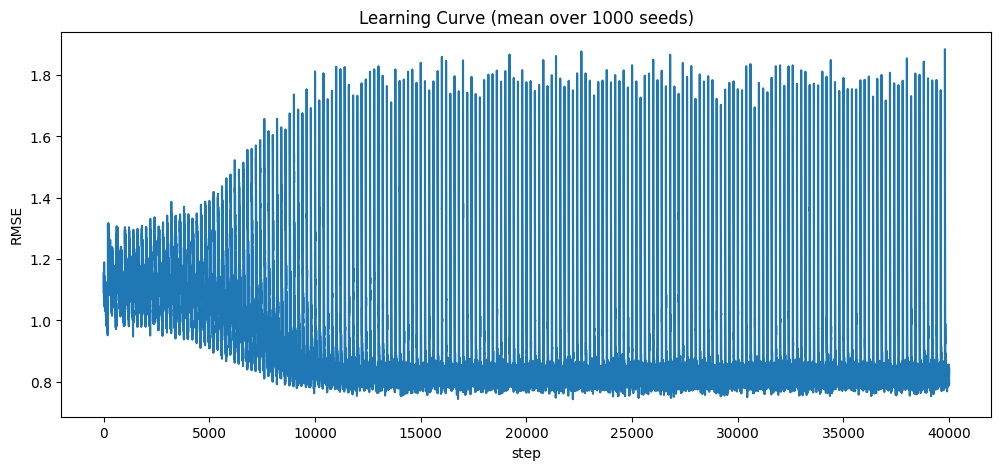

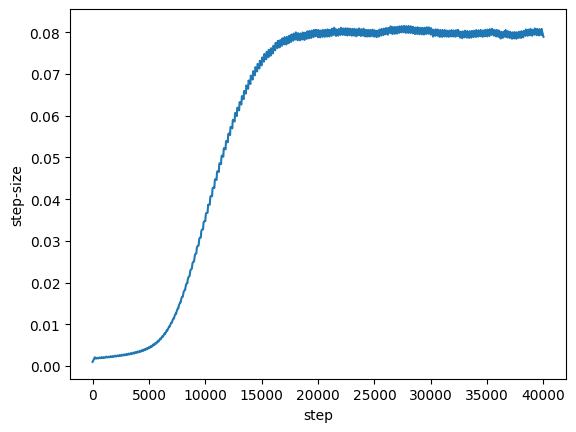

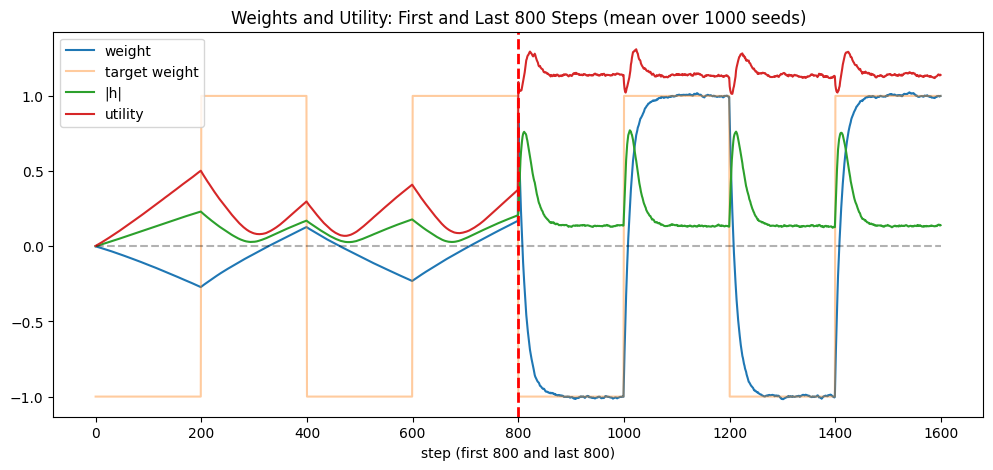

In [8]:
TRAIN_STEPS = 40_000
FLIP_PERIOD = 200
N_SEEDS = 1000

META_STEP_SIZE = 0.02
TAU = 1e4


def init_state(key):
    return dict(key=key, target_weight=1.0, step_size=0.001, weight=0.0, h=0.0, v=0.0)


@jax.jit
def step_fn(state, step):
    key, x_key, noise_key = jax.random.split(state['key'], 3)
    target_weight = jnp.where(step % FLIP_PERIOD == 0, -state['target_weight'], state['target_weight'])
    step_size, weight, h, v = state['step_size'], state['weight'], state['h'], state['v']

    x = jax.random.normal(x_key)
    target = target_weight * x + jax.random.normal(noise_key)
    pred = weight * x

    error = target - pred
    grad = error * x

    # Autostep meta-update
    v = jnp.maximum(jnp.abs(grad * h), v + step_size * x**2 / TAU * (jnp.abs(grad * h) - v))
    step_size = jnp.where(v != 0, step_size * jnp.exp(META_STEP_SIZE * grad * h / v), step_size)
    step_size /= jnp.maximum(step_size * x**2, 1)

    weight += step_size * grad
    h = h * jnp.maximum(0, 1 - step_size * x**2) + step_size * grad

    new_state = dict(key=key, target_weight=target_weight, step_size=step_size, weight=weight, h=h, v=v)
    out = dict(abs_error=jnp.abs(error), weight=weight, target_weight=target_weight, h=h, step_size=step_size)
    return new_state, out


keys = jax.random.split(jax.random.PRNGKey(0), N_SEEDS)
states = jax.vmap(init_state)(keys)
batched_step = jax.vmap(step_fn, in_axes=(0, None))
_, hist = jax.lax.scan(batched_step, states, jnp.arange(TRAIN_STEPS))  # leaves: (TRAIN_STEPS, N_SEEDS)

rmse_history = hist['abs_error'].mean(axis=1)
step_size_history = hist['step_size'].mean(axis=1)
weight_history = hist['weight'].mean(axis=1)
target_weight_history = hist['target_weight'].mean(axis=1)
abs_h_history = jnp.abs(hist['h']).mean(axis=1)
utility_history = (jnp.abs(hist['h']) + jnp.abs(hist['weight'])).mean(axis=1)

plt.figure(figsize=(12, 5))
plt.plot(rmse_history)
plt.title(f'Learning Curve (mean over {N_SEEDS} seeds)')
plt.ylabel('RMSE')
plt.xlabel('step')
plt.show()

plt.plot(step_size_history)
plt.ylabel('step-size')
plt.xlabel('step')
plt.show()

# Define how many steps to show at the start and end
n_display = 800

# Prepare data indices
start_idxs = np.arange(n_display)
end_idxs = np.arange(TRAIN_STEPS - n_display, TRAIN_STEPS)
middle_bar = n_display  # The step where start transitions to end in concatenated plot
steps_concat = np.arange(2 * n_display)

# Concatenate the two sections for plotting
concat = lambda a: np.concatenate([np.asarray(a)[start_idxs], np.asarray(a)[end_idxs]])

plt.figure(figsize=(12, 5))
plt.plot(steps_concat, concat(weight_history), label='weight')
plt.plot(steps_concat, concat(target_weight_history), alpha=0.4, label='target weight')
plt.plot(steps_concat, concat(abs_h_history), label='|h|')
plt.plot(steps_concat, concat(utility_history), label='utility')
plt.hlines(0, 0, 2 * n_display, alpha=0.3, linestyle='--', color='black')
plt.axvline(x=middle_bar, color='red', linestyle='--', linewidth=2.0)  # Vertical bar to separate
plt.xlabel(f'step (first {n_display} and last {n_display})')
plt.legend()
plt.title(f'Weights and Utility: First and Last {n_display} Steps (mean over {N_SEEDS} seeds)')
plt.show()

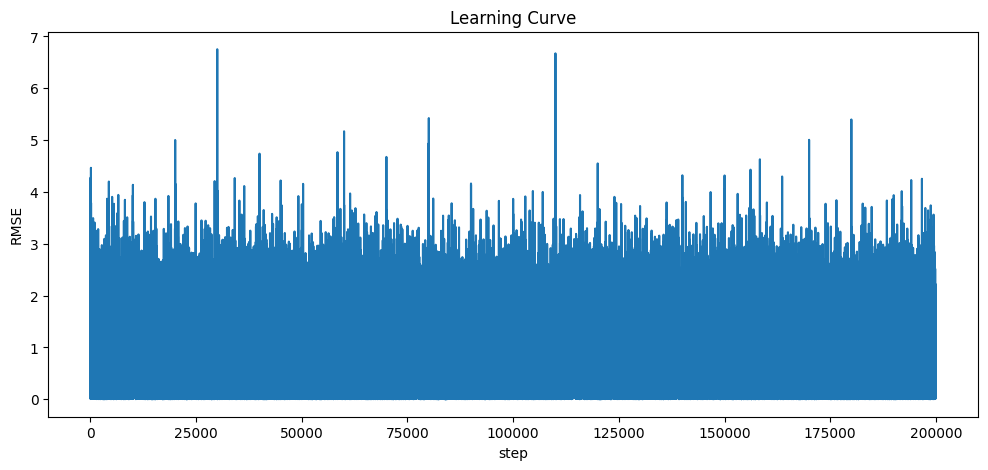

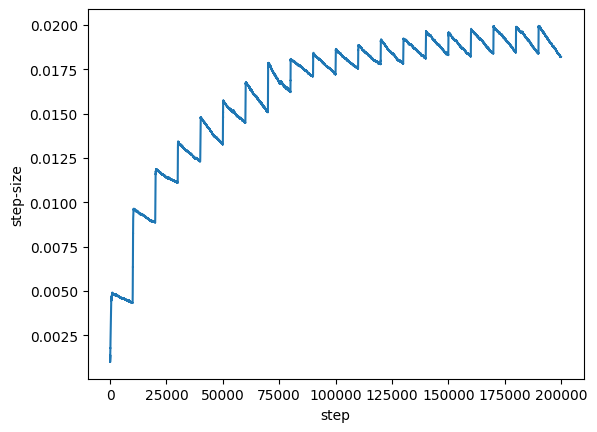

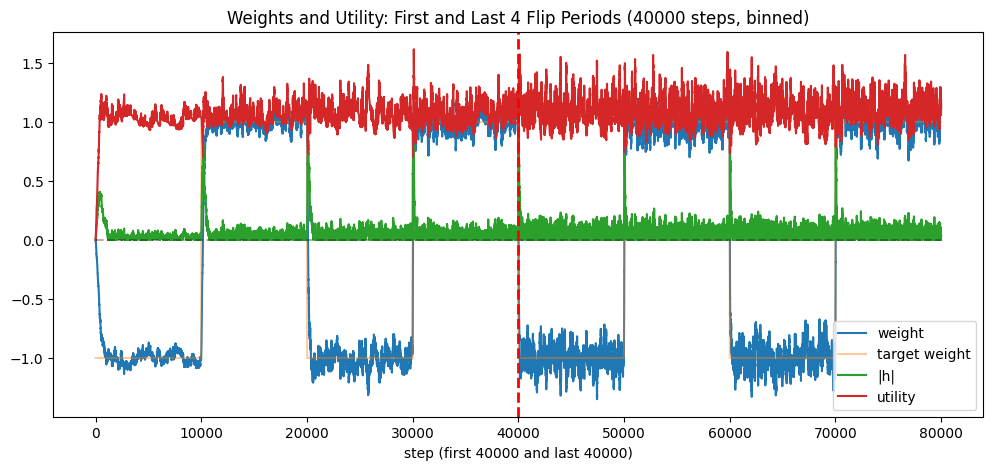

In [9]:
TRAIN_STEPS = 200_000
FLIP_PERIOD = 10_000  # Changed flip period to 2000

META_STEP_SIZE = 0.02
TAU = 1e4

target_weight = 1
step_size = 0.001
weight = 0
h = 0
v = 0

rmse_history = []
weight_history = []
target_weight_history = []
h_history = []
step_size_history = []

for step in range(TRAIN_STEPS):
    if step % FLIP_PERIOD == 0:
        target_weight = -target_weight
    
    x = np.random.randn()
    target = target_weight * x + np.random.randn()
    pred = weight * x
    
    error = target - pred
    grad = error * x

    # Autostep meta-update
    v = max(abs(grad * h), v + step_size * x**2 / TAU * (abs(grad * h) - v))
    if v != 0:
        step_size *= np.exp(META_STEP_SIZE * grad * h / v)
    step_size /= max(step_size * x**2, 1)

    weight += step_size * grad
    h = h * max(0, 1 - step_size * x**2) + step_size * grad
        
    rmse_history.append(np.abs(error))
    weight_history.append(weight)
    target_weight_history.append(target_weight)
    h_history.append(h)
    step_size_history.append(step_size)

BIN = 1  # Bin size for mean averaging

def bin_mean(arr, bin_size=BIN):
    arr = np.array(arr)
    n_bins = len(arr) // bin_size
    arr = arr[:n_bins * bin_size]
    arr_reshaped = arr.reshape(n_bins, bin_size)
    return arr_reshaped.mean(axis=1)

binned_rmse_history = bin_mean(rmse_history)
binned_step_size_history = bin_mean(step_size_history)

plt.figure(figsize=(12, 5))
plt.plot(np.arange(len(binned_rmse_history)) * BIN, binned_rmse_history)
plt.title('Learning Curve')
plt.ylabel('RMSE')
plt.xlabel('step')
plt.show()

plt.plot(np.arange(len(binned_step_size_history)) * BIN, binned_step_size_history)
plt.ylabel('step-size')
plt.xlabel('step')
plt.show()

# --- New logic below to make displayed regions exactly 4 flip periods each at start and end ---

flips_to_show = 4
steps_per_flip = FLIP_PERIOD
display_steps = flips_to_show * steps_per_flip

# Convert to binned space
start_idxs = np.arange(display_steps // BIN)
end_idxs = np.arange((len(weight_history) // BIN) - (display_steps // BIN), len(weight_history) // BIN)
bin_n_display = display_steps // BIN
middle_bar = bin_n_display  # Where start transitions to end in concatenated plot

def get_binned_concat(arr):
    arr = np.array(arr)
    n_bins = len(arr) // BIN
    arr = arr[:n_bins*BIN].reshape(n_bins, BIN).mean(axis=1)
    return np.concatenate([arr[start_idxs], arr[end_idxs]])

weight_concat = get_binned_concat(weight_history)
target_weight_concat = get_binned_concat(target_weight_history)
h_concat = get_binned_concat(h_history)
utility_concat = np.abs(h_concat) + np.abs(weight_concat)
steps_concat = np.arange(2 * bin_n_display) * BIN

plt.figure(figsize=(12, 5))
plt.plot(steps_concat, weight_concat, label='weight')
plt.plot(steps_concat, target_weight_concat, alpha=0.4, label='target weight')
plt.plot(steps_concat, np.abs(h_concat), label='|h|')
plt.plot(steps_concat, utility_concat, label='utility')
plt.hlines(0, 0, 2 * bin_n_display, alpha=0.3, linestyle='--', color='black')
plt.axvline(x=middle_bar * BIN, color='red', linestyle='--', linewidth=2.0)  # Vertical bar to separate
plt.xlabel(f'step (first {display_steps} and last {display_steps})')
plt.legend()
plt.title(f'Weights and Utility: First and Last {flips_to_show} Flip Periods ({display_steps} steps, binned)')
plt.show()


In [ ]:
import ipywidgets as widgets
import plotly.graph_objects as go
from scipy.special import erf

N_FLIPS = 4

# Gaussian closure for w' = w + a[(w*-w)x^2 + eps*x], h' = h(1 - a x^2) + a[(w*-w)x^2 + eps*x]
# State: (E[w], E[h], Var[w], Var[h], Cov[w,h]) with x, eps ~ N(0, 1) and a fixed.
def advance(state, target_weight, a):
    m, mu, s, q, r = state
    b, c, k = a * (target_weight - m), a * (target_weight - m - mu), 1 - 2 * a + 3 * a**2
    return ((1 - a) * m + a * target_weight,
            (1 - a) * mu + a * (target_weight - m),
            k * s + 2 * b**2 + a**2,
            k * q + 2 * c**2 + 3 * a**2 * s - 2 * a * r * (1 - 3 * a) + a**2,
            k * r - a * s * (1 - 3 * a) + 2 * b * c + a**2)

def fold_abs(mu, var):  # E|X| for X ~ N(mu, var)
    sd = np.sqrt(var)
    return sd * np.sqrt(2 / np.pi) * np.exp(-mu**2 / (2 * var)) + mu * erf(mu / (sd * np.sqrt(2)))

def steady_state(alpha, flip_period):
    n_burn = max(2, int(20 / (alpha * flip_period)) + 1)  # enough periods to reach the periodic fixed point
    state, target_weight, traj = (0.0,) * 5, 1.0, []
    for period in range(n_burn + N_FLIPS):
        target_weight = -target_weight
        for _ in range(flip_period):
            state = advance(state, target_weight, alpha)
            if period >= n_burn:
                traj.append(state + (target_weight,))
    m, mu, s, q, _, target_weights = np.array(traj).T
    abs_h, abs_w = fold_abs(mu, q), fold_abs(m, s)
    return np.arange(len(m)), (m, target_weights, abs_h, abs_h + abs_w)

Y_RANGE = [-1.5, 2.2]
fig = go.FigureWidget([go.Scatter(name=n, mode='lines') for n in ['weight', 'target weight', '|h|', 'utility']])
fig.data[1].opacity = 0.4
fig.update_layout(width=950, height=450, xaxis_title='step', yaxis_range=Y_RANGE,
                  margin=dict(t=40, b=40), template='plotly_white')

def update(alpha, flip_period):
    steps, ys = steady_state(alpha, flip_period)
    with fig.batch_update():  # one patch to the browser, no re-render
        for trace, y in zip(fig.data, ys):
            trace.x, trace.y = steps, y
        fig.layout.shapes = [dict(type='line', x0=f * flip_period, x1=f * flip_period,
                                  y0=Y_RANGE[0], y1=Y_RANGE[1], line=dict(color='red', dash='dash', width=1.5))
                             for f in range(1, N_FLIPS)]
        fig.layout.title = f'Analytic steady state | step size {alpha:.4f}, flip period {flip_period}'

controls = widgets.interactive(update,
    alpha=widgets.FloatLogSlider(value=0.08, base=10, min=-3, max=-0.5, step=0.01,
                                 description='step size', readout_format='.4f', continuous_update=True),
    flip_period=widgets.IntSlider(value=200, min=10, max=1000, step=10,
                                  description='flip period', continuous_update=True))
display(widgets.VBox([controls, fig]))
